# pipeline

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler,OneHotEncoder,FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import joblib
from utils import cap_outliers

cap_transformer = FunctionTransformer(cap_outliers)

In [2]:
num_cols=['Air temperature [K]','Process temperature [K]',
          'Rotational speed [rpm]','Torque [Nm]','Tool wear [min]']
cat_cols=['Type']

preprocessor=ColumnTransformer([
    ('scaler',StandardScaler(),num_cols),
    ('encoder',OneHotEncoder(handle_unknown='ignore'),cat_cols)
],remainder='passthrough')

In [3]:
pipeline=Pipeline([
    ('cap_outliers',cap_transformer),
    ('preprocessing',preprocessor),
    ('model',XGBClassifier(random_state=42))
])

In [4]:
pipeline

,steps,"[('cap_outliers', ...), ('preprocessing', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<function cap...00167363C4360>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None


In [5]:
df=pd.read_csv(r"C:\Users\Sarvadnya\FUSIONCLASS\Predictive_maintenance_project\predictive_maintenance.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


<Axes: >

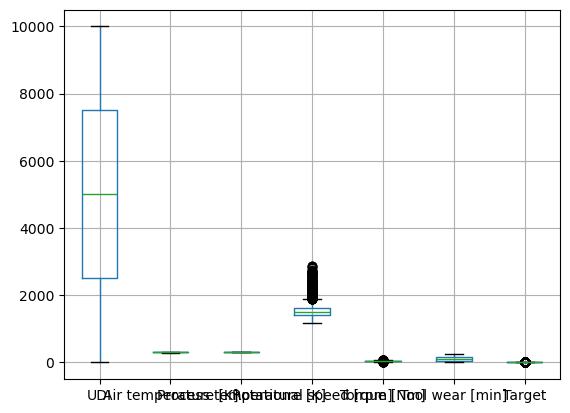

In [6]:
df.boxplot()

In [7]:
df.drop(columns=['UDI','Product ID','Failure Type'],inplace=True)

In [9]:
# split your dataset
x=df.drop(columns=['Target'])
y=df['Target']

In [10]:
x

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,M,298.1,308.6,1551,42.8,0
1,L,298.2,308.7,1408,46.3,3
2,L,298.1,308.5,1498,49.4,5
3,L,298.2,308.6,1433,39.5,7
4,L,298.2,308.7,1408,40.0,9
...,...,...,...,...,...,...
9995,M,298.8,308.4,1604,29.5,14
9996,H,298.9,308.4,1632,31.8,17
9997,M,299.0,308.6,1645,33.4,22
9998,H,299.0,308.7,1408,48.5,25


In [11]:
pipeline.fit(x,y)

,steps,"[('cap_outliers', ...), ('preprocessing', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<function cap...00167363C4360>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None


In [13]:
# save for deployment
joblib.dump(pipeline,'test.pkl')

['test.pkl']